# Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../dataset/heart_disease.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [4]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [5]:
numerical_features = df.select_dtypes(include='float64').columns
categorical_features = df.select_dtypes(include='str').columns

## Univariate Analysis

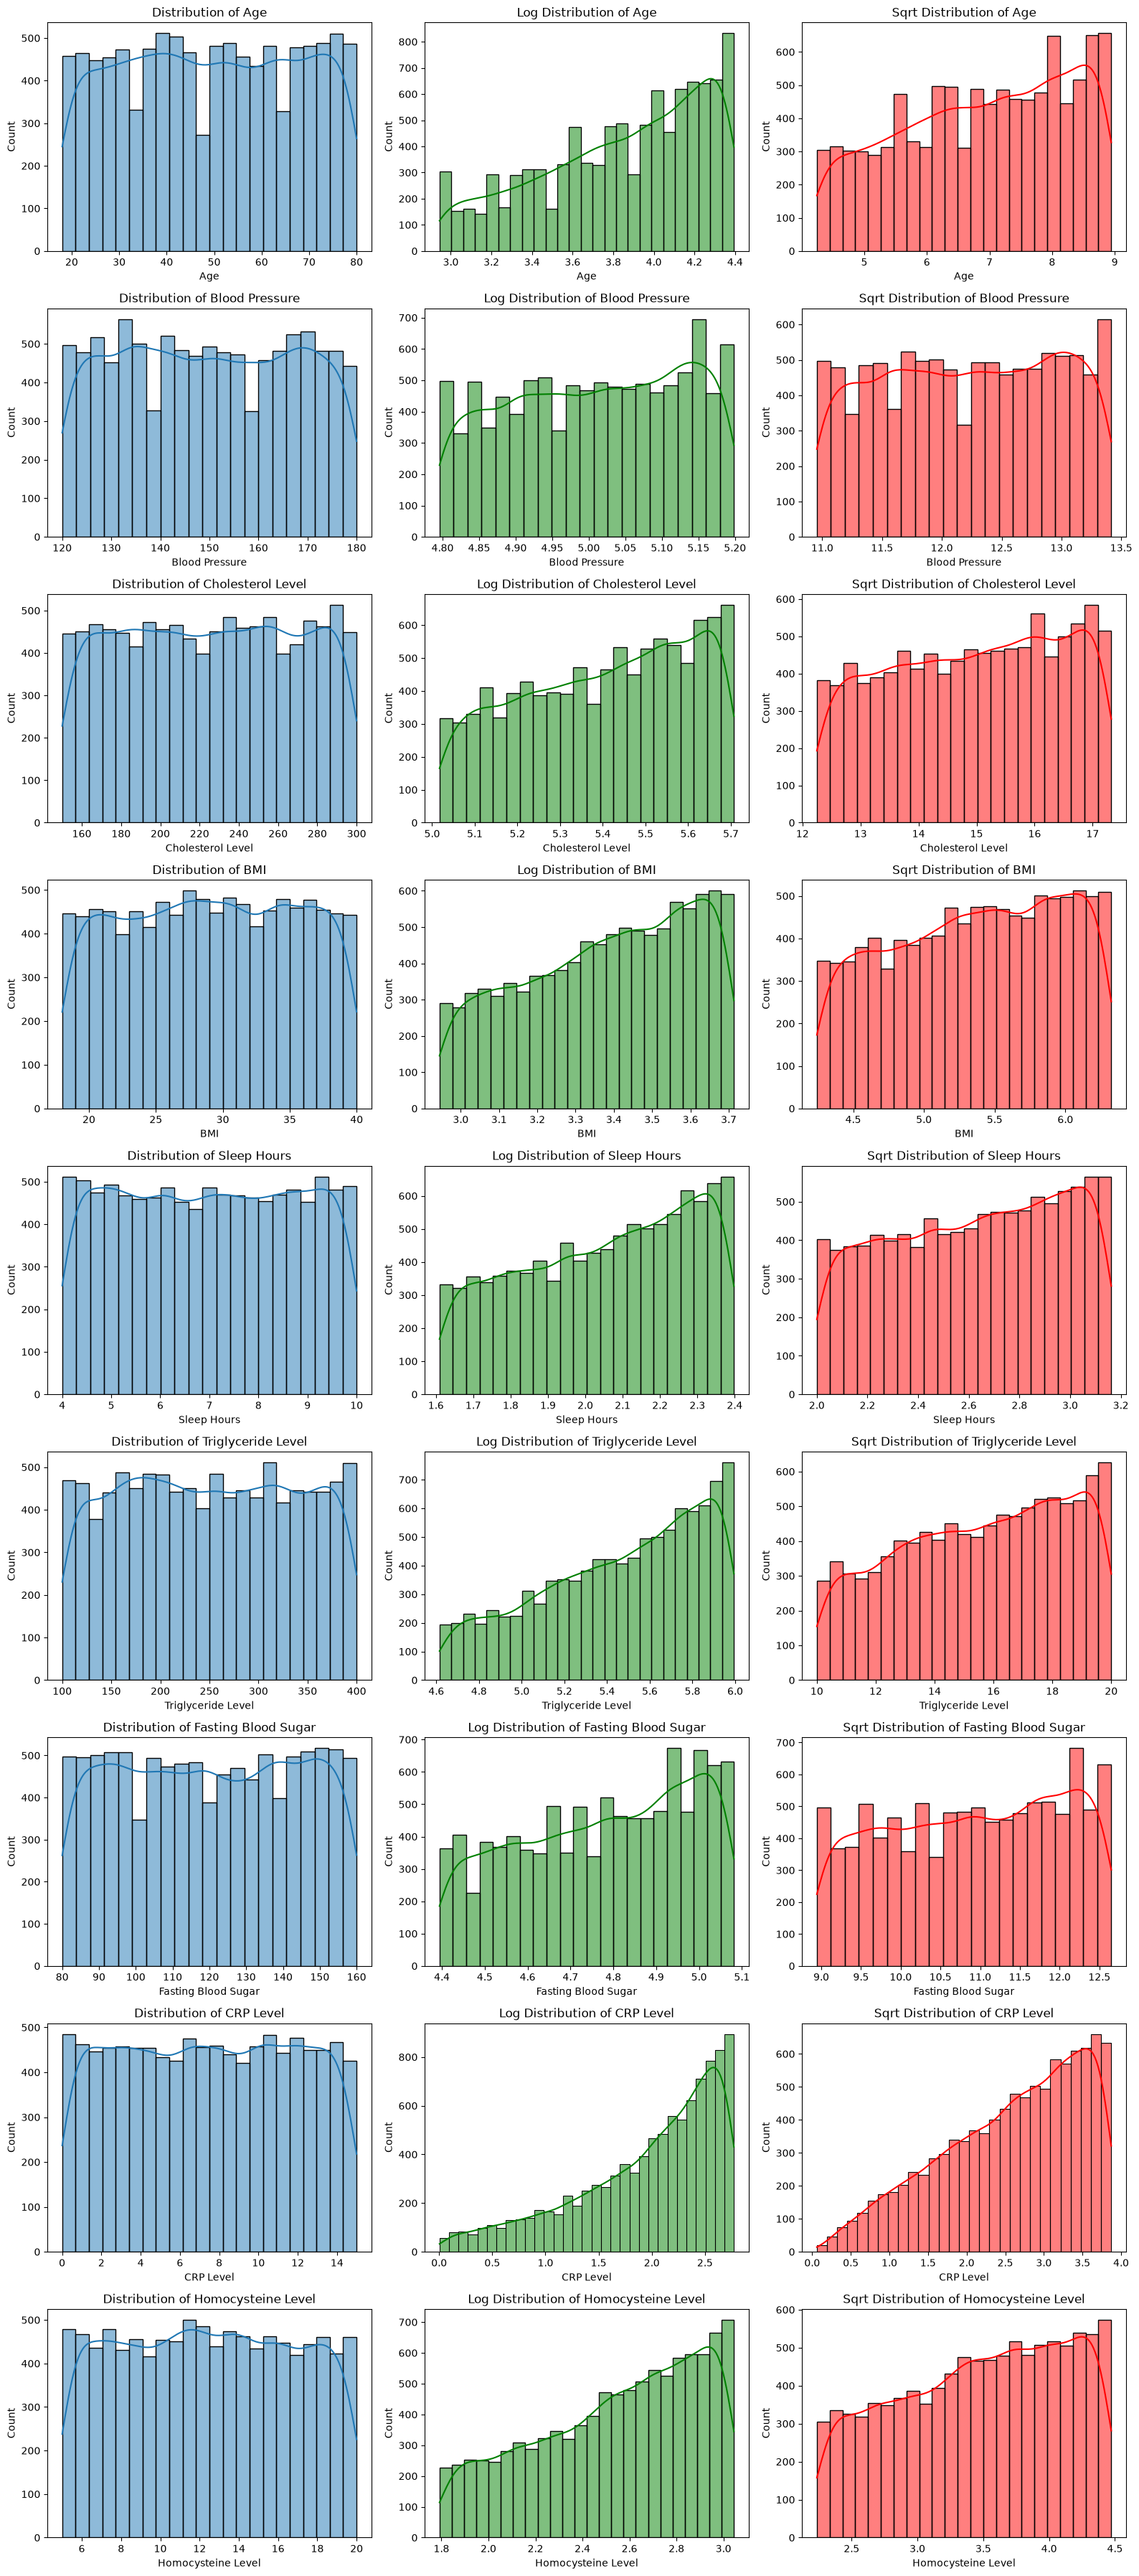

In [6]:
fig, axes = plt.subplots(len(numerical_features), 3, figsize=(16, 4
*len(numerical_features)))

for i,col in enumerate(numerical_features):

    sns.histplot(df[col], kde=True, ax=axes[i][0])
    axes[i][0].set_title(f"Distribution of {col}")

    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[i][1], color='green')
    axes[i][1].set_title(f"Log Distribution of {col}")

    sns.histplot(np.sqrt(df[col]), kde=True, ax=axes[i][2], color='red')
    axes[i][2].set_title(f"Sqrt Distribution of {col}")

plt.tight_layout()
plt.show()

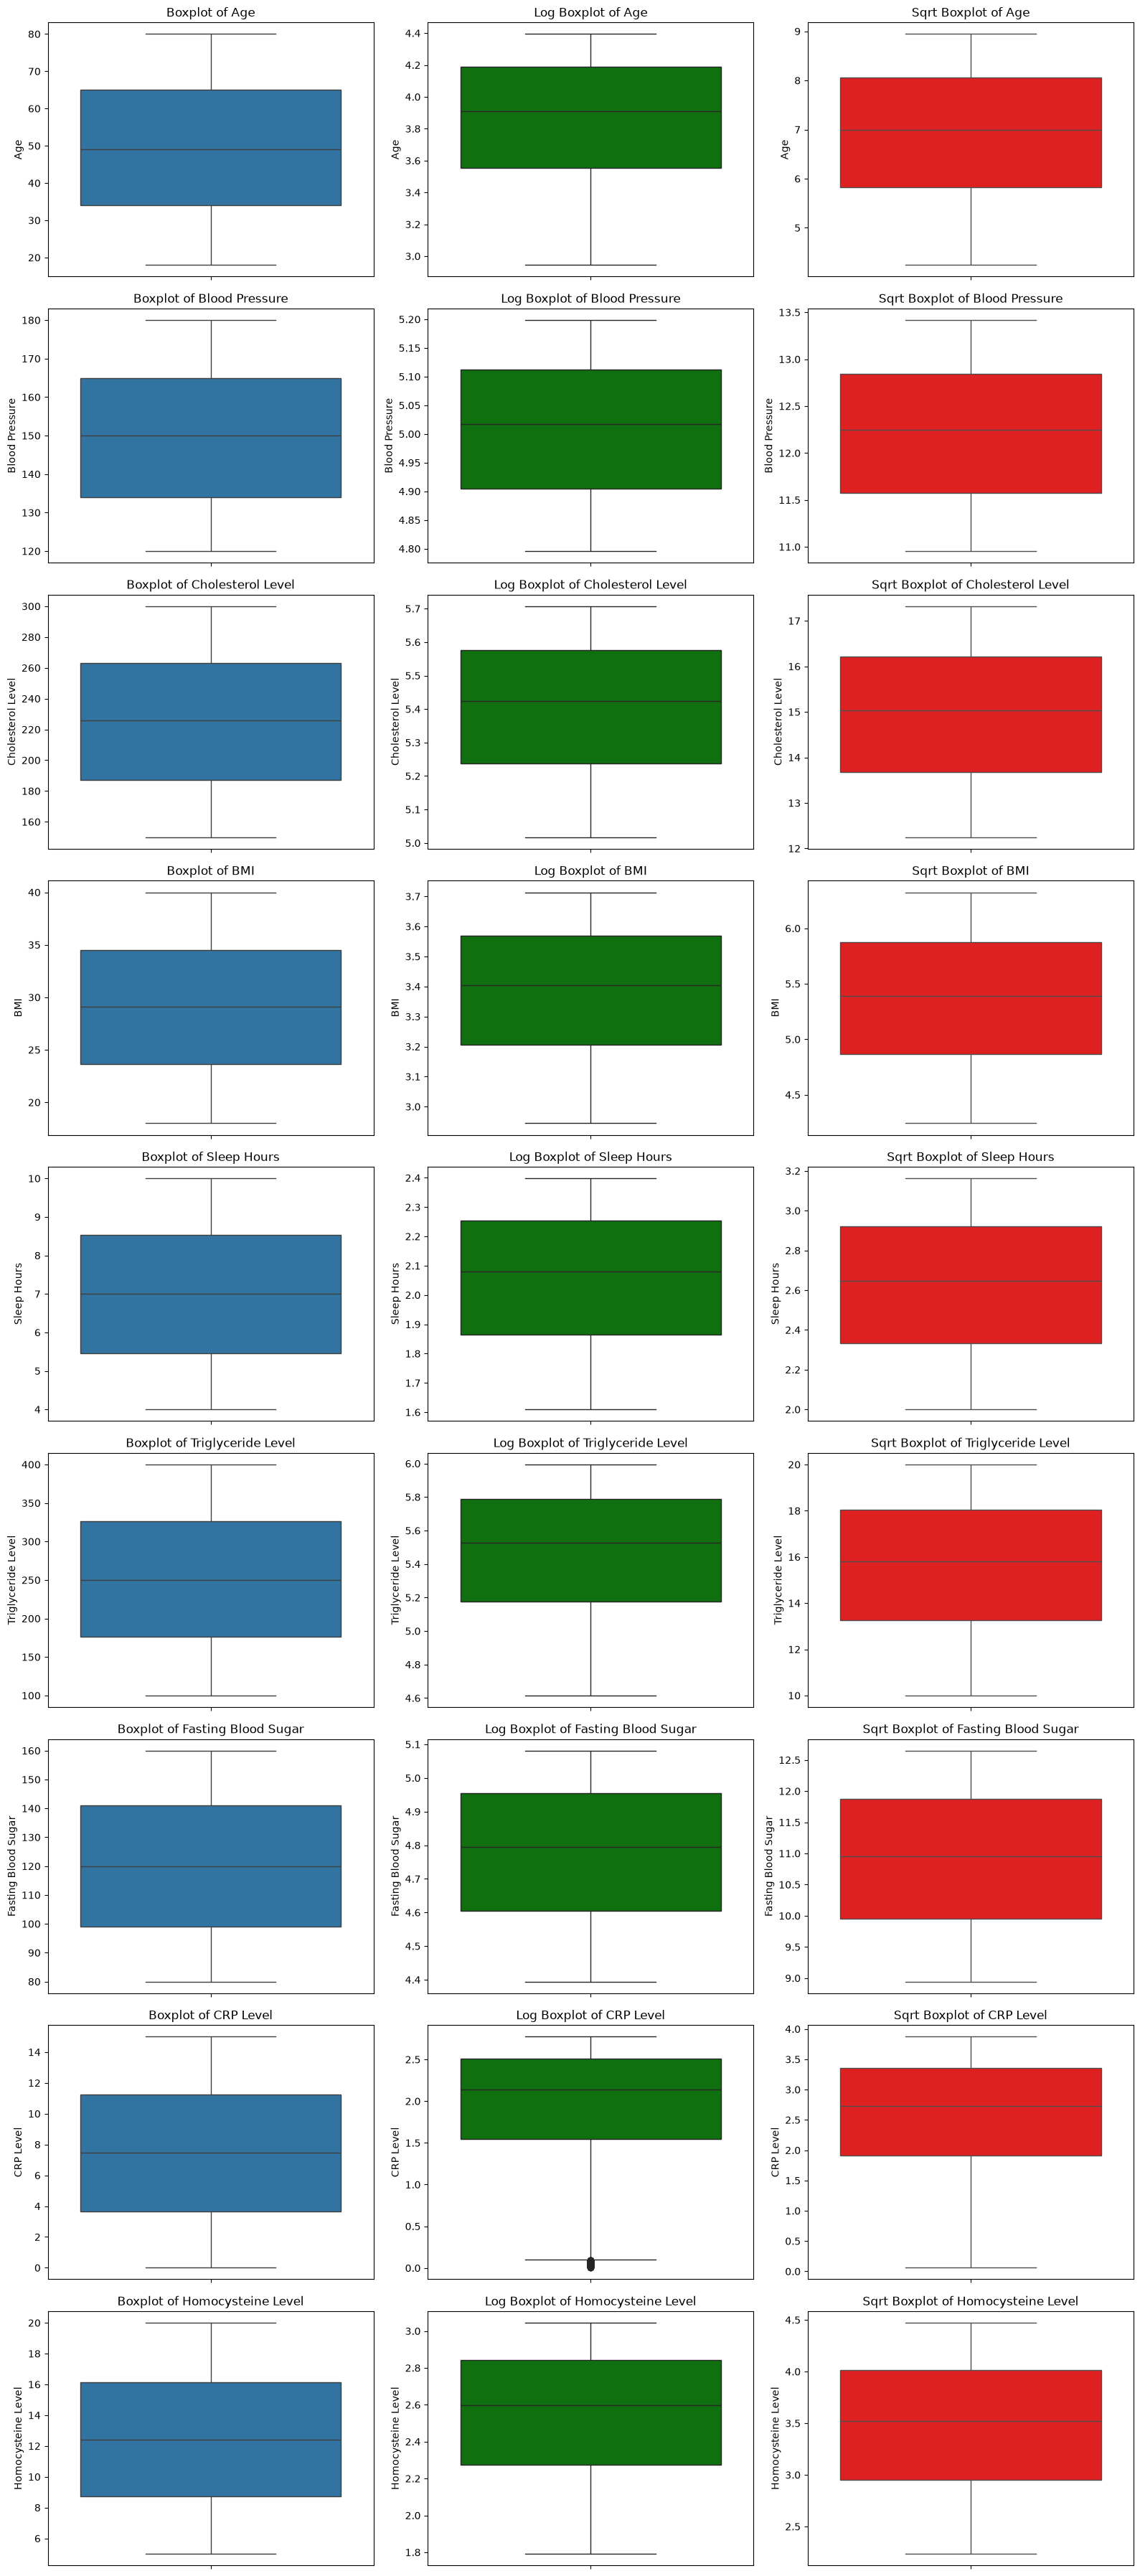

In [7]:
fig, axes = plt.subplots(len(numerical_features), 3, figsize=(16, 4
*len(numerical_features)))

for i,col in enumerate(numerical_features):

    sns.boxplot(df[col], ax=axes[i][0])
    axes[i][0].set_title(f"Boxplot of {col}")

    sns.boxplot(np.log1p(df[col]), ax=axes[i][1], color='green')
    axes[i][1].set_title(f"Log Boxplot of {col}")

    sns.boxplot(np.sqrt(df[col]), ax=axes[i][2], color='red')
    axes[i][2].set_title(f"Sqrt Boxplot of {col}")

plt.tight_layout()
plt.show()

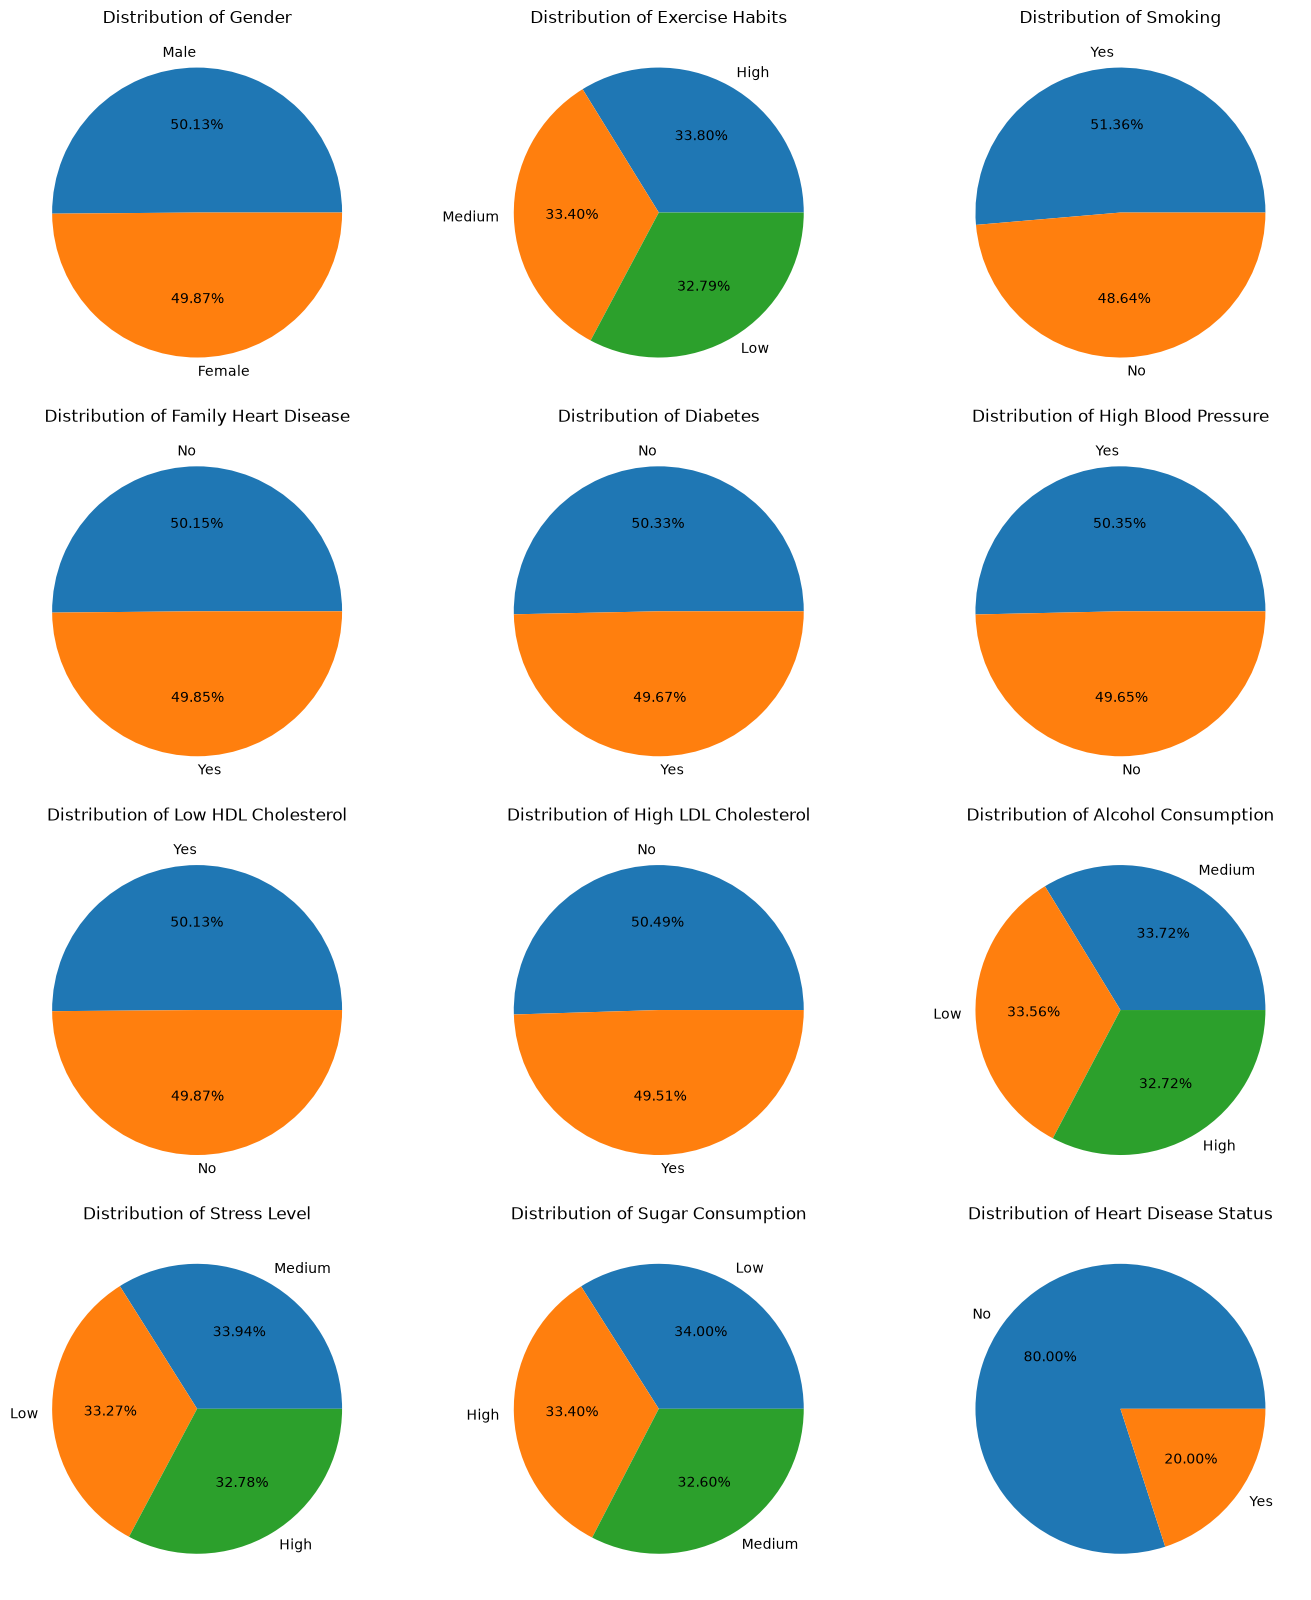

In [8]:
rows = len(categorical_features) + 1 // 3
fig, axes = plt.subplots(rows, 3, figsize=(14, 4*rows))

axes = axes.flatten()

for i, col in enumerate(categorical_features):
    data = df[col].value_counts()

    axes[i].pie(data, labels=data.index, autopct="%1.2f%%")
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Bivariate Analysis

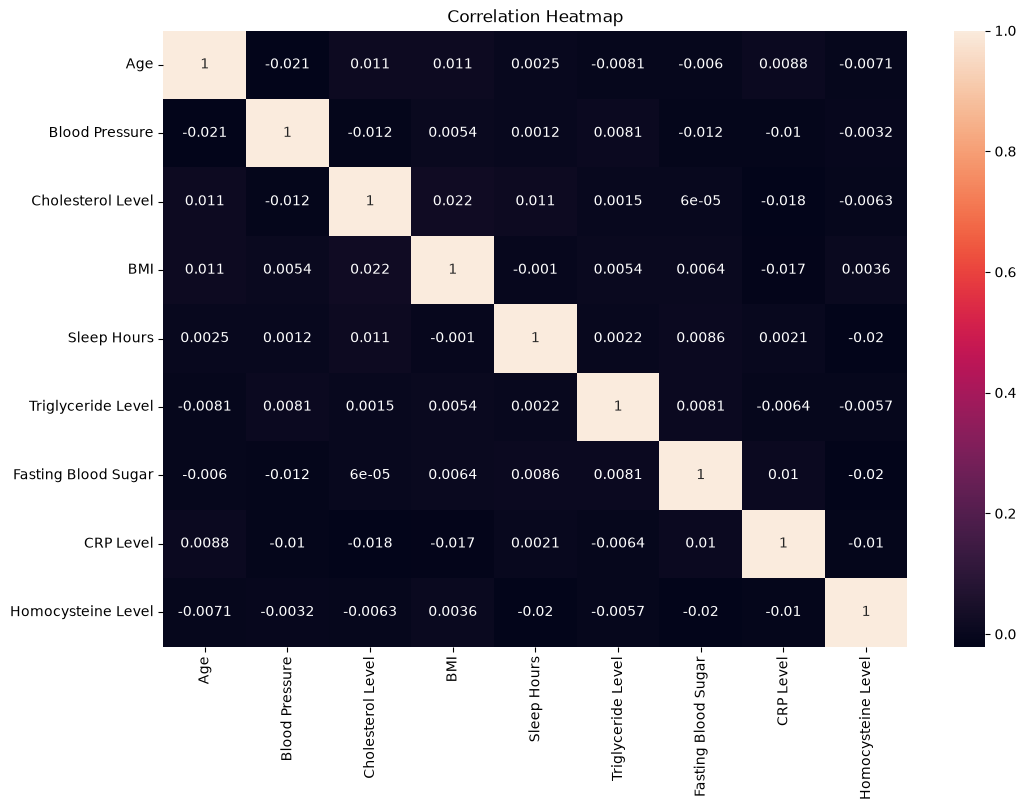

In [9]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include='float64').corr()
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

## Observations

### Histograms
- On comparing the distributions of the numerical features, we can see that applying transformations like log or sqrt is resulting in left skewness of data
- Therefore, there is no need to apply any transformations on the data

### Box Plots
- The box plots for all the numerical features does not indicate any outliers
- Also, the box plots for the log and sqrt distributions tend to have a higher median than the regular boxplot, indicating a left skew in the transformations as expected

### Pie Charts

- All categorical features are balanced properly except the target variable (Heart Disease Status) which has a huge class imbalance
- While training the ML model, ensure to take into consideration the given class imbalance

### Heatmap

- Heatmap shows no correlation between any two numerical features as all values are close to 0
- This observation might suggest that simple models like Logistic Regression may perform poorly and may require the use of models like Random Forest, SVM etc